# RNN / LSTM Language Models — the Pre-Transformer Baseline

Before attention and Transformers, sequence models were **recurrent**: they read tokens one at
a time, carrying a **hidden state** that summarizes everything seen so far.

$$h_t = f(h_{t-1},\, x_t) \qquad \hat{y}_t = \text{softmax}(W\,h_t)$$

In this notebook we train two word-level next-word predictors in PyTorch — a vanilla **RNN**
and an **LSTM** — and compare them. This sets up *why* the Transformer was needed:

- **Sequential computation:** step $t$ depends on step $t-1$, so training cannot be parallelized
  across the sequence (unlike the Transformer).
- **Vanishing gradients:** plain RNNs struggle to carry information across long distances. The
  **LSTM** adds gates to mitigate this — but only partly.

> This is the historical contrast for `08_attention.ipynb` and `09_transformer.ipynb`.

In [1]:
import sys
import os
import random
from collections import Counter

sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset

%matplotlib inline

torch.manual_seed(42)
random.seed(42)

# Goal: train a simple RNN-based language model
# to predict the next word from a small context window.

## 1. Corpus and Word-Level Vocabulary

We load TinyStories and tokenize at the **word** level. Special tokens `<pad>` and `<unk>` handle padding and out-of-vocabulary words.

In [2]:
# Load the corpus and build a word-level vocabulary
corpus = open('../database/TinyStories-valid.txt', 'r', encoding='utf-8').read()
words = corpus.split()
print(len(words))

max_tokens = 300_000
if len(words) > max_tokens:
    words = words[:max_tokens]

word_counts = Counter(words)
vocab = ['<pad>', '<unk>'] + sorted(word_counts.keys())
word2id = {word: idx for idx, word in enumerate(vocab)}
id2word = {idx: word for word, idx in word2id.items()}
encoded_words = [word2id.get(word, word2id['<unk>']) for word in words]
vocab_size = len(vocab)

print(f'Tokens used: {len(words):,}')
print(f'Vocabulary size: {vocab_size:,}')
print(f'First words: {words[:12]}')

3775640
Tokens usados: 300,000
Tamanho do vocabulario: 12,992
Primeiras palavras: ['Spot.', 'Spot', 'saw', 'the', 'shiny', 'car', 'and', 'said,', '"Wow,', 'Kitty,', 'your', 'car']


## 2. Context Windows: Train/Validation Split

The model sees a fixed window of `sequence_length` previous words and predicts the next one. We split the token stream 90/10 into train/validation.

In [3]:
# Train/validation split and context-window size
sequence_length = 6
split_idx = int(len(encoded_words) * 0.9)

train_tokens = encoded_words[:split_idx]
val_tokens = encoded_words[split_idx - sequence_length:]

print(f'Training tokens: {len(train_tokens):,}')
print(f'Validation tokens: {len(val_tokens):,}')
print(f'Encoded context example: {train_tokens[:sequence_length]} -> {train_tokens[sequence_length]}')

Tokens de treino: 270,000
Tokens de validacao: 30,006
Exemplo de contexto codificado: [1359, 1356, 9653, 11406, 9969, 2973] -> 1806


## 3. Dataset and DataLoader

`NextWordDataset` yields `(context, next_word)` pairs; the `DataLoader` batches and shuffles them.

In [4]:
class NextWordDataset(Dataset):
    def __init__(self, tokens, sequence_length):
        self.tokens = tokens
        self.sequence_length = sequence_length

    def __len__(self):
        return len(self.tokens) - self.sequence_length

    def __getitem__(self, idx):
        x = self.tokens[idx : idx + self.sequence_length]
        y = self.tokens[idx + self.sequence_length]
        return torch.tensor(x, dtype=torch.long), torch.tensor(y, dtype=torch.long)


batch_size = 128
train_dataset = NextWordDataset(train_tokens, sequence_length)
val_dataset = NextWordDataset(val_tokens, sequence_length)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

x_batch, y_batch = next(iter(train_loader))
print(f'Input batch shape: {tuple(x_batch.shape)}')
print(f'Target batch shape: {tuple(y_batch.shape)}')
print('First batch example (ids):', x_batch[0].tolist(), '->', y_batch[0].item())

Formato do lote de entrada: (128, 6)
Formato do lote alvo: (128,)
Primeiro exemplo do lote (ids): [3663, 12260, 11631, 8612, 6463, 1806] -> 7199


## 4. The Recurrent Model (RNN and LSTM)

The same architecture is reused for both cell types: **Embedding → recurrent layer → Linear**.
Only the **last** hidden state feeds the output projection, since we predict a single next word.

- **`nn.RNN`**: simple recurrence, prone to vanishing gradients.
- **`nn.LSTM`**: adds input/forget/output gates and a cell state to preserve long-range info.

In [5]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', device)


class RecurrentLanguageModel(nn.Module):
    def __init__(self, vocab_size, cell_type='rnn', embed_dim=64, hidden_size=128):
        super().__init__()
        self.cell_type = cell_type.lower()
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        recurrent_layers = {
            'rnn': nn.RNN,
            'lstm': nn.LSTM,
        }
        if self.cell_type not in recurrent_layers:
            raise ValueError(f'invalid cell_type: {cell_type}')

        self.recurrent = recurrent_layers[self.cell_type](embed_dim, hidden_size, batch_first=True)
        self.output = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden=None):
        embeddings = self.embedding(x)
        recurrent_out, hidden = self.recurrent(embeddings, hidden)
        logits = self.output(recurrent_out[:, -1, :])
        return logits, hidden


def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters())


loss_fn = nn.CrossEntropyLoss()
rnn_model = RecurrentLanguageModel(vocab_size=vocab_size, cell_type='rnn').to(device)
lstm_model = RecurrentLanguageModel(vocab_size=vocab_size, cell_type='lstm').to(device)

print(f'RNN parameters: {count_parameters(rnn_model):,}')
print(f'LSTM parameters: {count_parameters(lstm_model):,}')

Dispositivo: cuda
Parametros RNN: 2,532,288
Parametros LSTM: 2,606,784


## 5. Training, Generation, and RNN vs LSTM Comparison

We train both models with Adam + gradient clipping, sample text autoregressively (with temperature), and compare validation loss.


Treinando RNN
Epoca 1: train_loss=5.4630 | val_loss=5.1616
  Geracao exemplo: Once upon a time there was a sweet who decided to have any Each a big smile and showed it to the worried around
Epoca 2: train_loss=4.4921 | val_loss=4.9503
  Geracao exemplo: Once upon a time there was a hot old duck was very excited the thief started to you." Lily was so happy to give
Epoca 3: train_loss=4.1103 | val_loss=4.8900
  Geracao exemplo: Once upon a time there was a little girl named Lily. She loved to play with the fish, of new things. The generous was
Epoca 4: train_loss=3.8500 | val_loss=4.8996
  Geracao exemplo: Once upon a time there was a little dog named Timmy. He loved to jump in his bag and let her dad who could
Epoca 5: train_loss=3.6457 | val_loss=4.9324
  Geracao exemplo: Once upon a time there was a little girl named Lucy. She was very excited and she was going. The little girl said no.
Epoca 6: train_loss=3.4759 | val_loss=4.9804
  Geracao exemplo: Once upon a time there was a littl

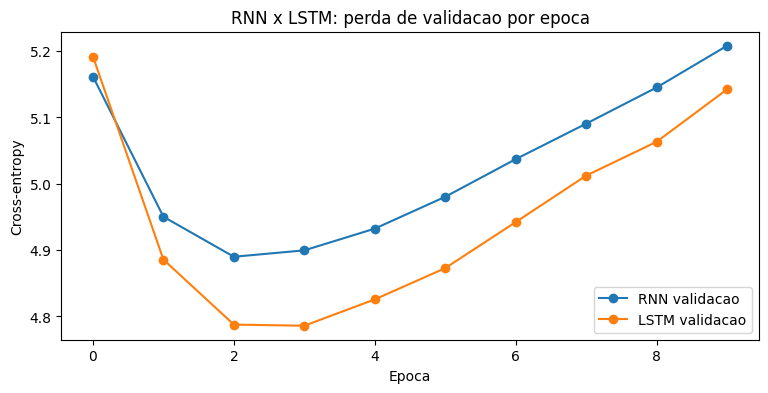


Resumo da comparacao
RNN: parametros=2,532,288 | train_final=2.9750 | melhor_val=4.8900
LSTM: parametros=2,606,784 | train_final=2.7805 | melhor_val=4.7860

Geracao com a RNN:
Once upon a time there was a little girl who loved to play with his sword and one before his friend ears came to the tent. He was so

Geracao com a LSTM:
Once upon a time there was a little girl. It was flying as the old man wanted to play his mom but Tim were scared. Lily told her mommy


In [7]:
def run_epoch(model, dataloader, loss_fn, optimizer=None):
    is_training = optimizer is not None
    model.train(is_training)
    total_loss = 0.0

    for x, y in dataloader:
        x = x.to(device)
        y = y.to(device)

        logits, _ = model(x)
        loss = loss_fn(logits, y)

        if is_training:
            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(dataloader.dataset)


def train_model(model, train_loader, val_loader, loss_fn, epochs=10, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    train_history = []
    val_history = []

    for epoch in range(1, epochs + 1):
        train_loss = run_epoch(model, train_loader, loss_fn, optimizer)
        val_loss = run_epoch(model, val_loader, loss_fn)
        train_history.append(train_loss)
        val_history.append(val_loss)

        print(f'Epoch {epoch}: train_loss={train_loss:.4f} | val_loss={val_loss:.4f}')
        g_text = generate_text(model, 'Once upon a time', max_new_tokens=20, temperature=0.8)
        print(f'  Sample generation: {g_text}')

    return train_history, val_history


def generate_text(model, seed_text, max_new_tokens=20, temperature=1.0):
    model.eval()
    seed_ids = [word2id.get(word, word2id['<unk>']) for word in seed_text.split()]
    context = ([word2id['<pad>']] * sequence_length + seed_ids)[-sequence_length:]
    generated_ids = seed_ids.copy()

    with torch.no_grad():
        for _ in range(max_new_tokens):
            x = torch.tensor([context], dtype=torch.long, device=device)
            logits, _ = model(x)
            logits = logits / temperature
            probs = torch.softmax(logits[0], dim=0)
            next_id = torch.multinomial(probs, num_samples=1).item()
            generated_ids.append(next_id)
            context = context[1:] + [next_id]

    return ' '.join(id2word[idx] for idx in generated_ids)


models = {
    'RNN': RecurrentLanguageModel(vocab_size=vocab_size, cell_type='rnn').to(device),
    'LSTM': RecurrentLanguageModel(vocab_size=vocab_size, cell_type='lstm').to(device),
}
comparison_results = {}
prompt = 'Once upon a time'

for model_name, current_model in models.items():
    torch.manual_seed(42)
    if device == 'cuda':
        torch.cuda.manual_seed_all(42)

    print(f'\nTraining {model_name}')
    train_history, val_history = train_model(current_model, train_loader, val_loader, loss_fn)
    generated_text = generate_text(current_model, prompt, max_new_tokens=25, temperature=0.9)
    comparison_results[model_name] = {
        'train_history': train_history,
        'val_history': val_history,
        'best_val_loss': min(val_history),
        'last_train_loss': train_history[-1],
        'generated_text': generated_text,
        'params': count_parameters(current_model),
    }

plt.figure(figsize=(9, 4))
for model_name, result in comparison_results.items():
    plt.plot(result['val_history'], marker='o', label=f'{model_name} validation')
plt.title('RNN vs LSTM: validation loss per epoch')
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy')
plt.legend()
plt.show()

print('\nComparison summary')
for model_name, result in comparison_results.items():
    print(
        f"{model_name}: params={result['params']:,} | "
        f"train_final={result['last_train_loss']:.4f} | "
        f"best_val={result['best_val_loss']:.4f}"
    )

print('\nGeneration with the RNN:')
print(comparison_results['RNN']['generated_text'])
print('\nGeneration with the LSTM:')
print(comparison_results['LSTM']['generated_text'])

## Conclusion: Why the Transformer Replaced RNNs

The LSTM usually beats the plain RNN here (better gates → better long-range memory), but both
share two fundamental limits:

1. **No parallelism over time** — hidden states must be computed sequentially, so long sequences
   train slowly.
2. **Limited long-range dependencies** — information still degrades over many steps.

The **Transformer** fixes both: **self-attention** lets every position look directly at every
other position in **one parallel operation** — no recurrence, constant path length between any
two tokens. Continue with `08_attention.ipynb`.